Edep-sim Segment Study
======================

## Units from h5 files (dumpTree)

MeV, cm, µs

## LAr Geometry

X is the drift direction, vertical \
Xmin = -425.0cm \
Xmax = 425.08cm \
Cathode = -325cm \
CRP = 325cm \
Ymin = -753.8024cm \
Ymax = 753.8024cm \
Zmin = -107.0cm \
Zmax = 2198.88cm

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fName = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'

In [3]:
with h5py.File(fName, 'r') as f:
    # Print all top-level groups/datasets
    print(list(f.keys()))
    fS = f['segments']
    fT = f['trajectories']
    fV = f['vertices']
    print(fS.dtype)
    print(fT.dtype)
    print(fV.dtype)
    
    tempS = fS[()]
    tempT = fT[()]
    tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144], 'itemsize': 152}
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process

In [4]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,long_diff,pixel_plane,t_end,dEdx,dE,t,y,x,z,n_photons
0,0,0,0,0,1113.118896,0,0,0.0,1113.115845,-309.159698,...,0.0,0,0.0,24.895210,0.102955,0.0,-26.064362,-309.160126,1113.117432,0.0
1,0,0,1,1,1103.693604,0,1,0.0,1103.678223,-395.968414,...,0.0,0,0.0,13.062375,0.272483,0.0,146.634644,-395.965881,1103.685913,0.0
2,0,0,2,2,1062.674561,0,2,0.0,1062.677002,268.650177,...,0.0,0,0.0,26.654310,0.091932,0.0,127.297485,268.649109,1062.675781,0.0
3,0,0,3,3,1056.802979,0,3,0.0,1056.802979,322.655792,...,0.0,0,0.0,143.201324,0.010307,0.0,-87.979385,322.655762,1056.802979,0.0
4,0,0,4,4,1177.411621,0,4,0.0,1177.421631,13.592563,...,0.0,0,0.0,11.276511,0.354154,0.0,49.331459,13.584973,1177.416626,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7810663,999,0,2092314,7810663,913.489563,4,7544615,0.0,913.489380,368.043304,...,0.0,0,0.0,75.900673,0.014933,0.0,97.306595,368.043335,913.489502,0.0
7810664,999,0,2092314,7810664,910.598145,3,7544614,0.0,910.598206,366.257172,...,0.0,0,0.0,106.391434,0.010890,0.0,98.160988,366.257141,910.598145,0.0
7810665,999,0,2092314,7810665,905.926636,2,7544613,0.0,905.927124,360.396118,...,0.0,0,0.0,25.927198,0.095185,0.0,93.209824,360.397797,905.926880,0.0
7810666,999,0,2092314,7810666,905.608215,1,7544612,0.0,905.658447,363.002106,...,0.0,0,0.0,2.870945,0.462118,0.0,93.861130,362.933380,905.633301,0.0


In [5]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT[dT.file_vertex_id<3]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
0,0,0,0,0,0,-1,True,0.613954,"[0.0682862177491188, 0.21526359021663666, 0.25...","[-309.1605529785156, -26.065690994262695, 1113...",...,0.510999,"[0.0, 0.0, 0.0]","[-309.1596984863281, -26.063034057617188, 1113...",3679.103434,11,0,0,2,22,0.004200
1,0,0,1,0,1,-1,True,0.783480,"[-0.14507721364498138, -0.3742099404335022, 0....","[-395.96331787109375, 146.64120483398438, 1103...",...,0.510999,"[-0.0, -0.0, 0.0]","[-395.9684143066406, 146.62806701660156, 1103....",3642.347754,11,2,22,2,22,0.020858
2,0,0,2,0,2,-1,True,0.602932,"[0.20221948623657227, -0.10365697741508484, -0...","[268.64801025390625, 127.29804229736328, 1062....",...,0.510999,"[0.0, -0.0, -0.0]","[268.6501770019531, 127.29692840576172, 1062.6...",-1905.684382,11,2,22,2,22,0.003460


In [6]:
# create a dataframe for fixing the color code
pdgCodes = dT.pdg_id.unique()

particleName = np.array([ 'electron', 'photon', 'alpha', 'positron', 'neutron', 
                          'Ar41', 'Ar40', 'Ca43',
                         ])

pdgDF = pd.DataFrame({ 'pdgCode': pdgCodes, 'name': particleName })

pdgDF

,pdgCode,name
0,11,electron
1,22,photon
2,1000020040,alpha
3,-11,positron
4,2112,neutron
5,1000180410,Ar41
6,1000180400,Ar40
7,1000200430,Ca43


In [7]:
palette = plt.get_cmap("tab10").colors[:8]
colorAll = plt.get_cmap("tab10").colors[8]

# build mapping using pdgDF order
code_to_color = dict(zip(pdgDF["pdgCode"], palette))

# add to pdgDF
pdgDF["color"] = pdgDF["pdgCode"].map(code_to_color)

pdgDF

,pdgCode,name,color
0,11,electron,"(0.12156862745098039, 0.4666666666666667, 0.70..."
1,22,photon,"(1.0, 0.4980392156862745, 0.054901960784313725)"
2,1000020040,alpha,"(0.17254901960784313, 0.6274509803921569, 0.17..."
3,-11,positron,"(0.8392156862745098, 0.15294117647058825, 0.15..."
4,2112,neutron,"(0.5803921568627451, 0.403921568627451, 0.7411..."
5,1000180410,Ar41,"(0.5490196078431373, 0.33725490196078434, 0.29..."
6,1000180400,Ar40,"(0.8901960784313725, 0.4666666666666667, 0.760..."
7,1000200430,Ca43,"(0.4980392156862745, 0.4980392156862745, 0.498..."


## Segment feature

### Energy

In [8]:
dS.dE.min(), dS.dE.max()

(1.5279510989785194e-09, 8.785100936889648)

In [9]:
dS.pdg_id.unique()

array([        11,         22, 1000020040,        -11,       2112,
       1000180410, 1000180400, 1000200430], dtype=int32)

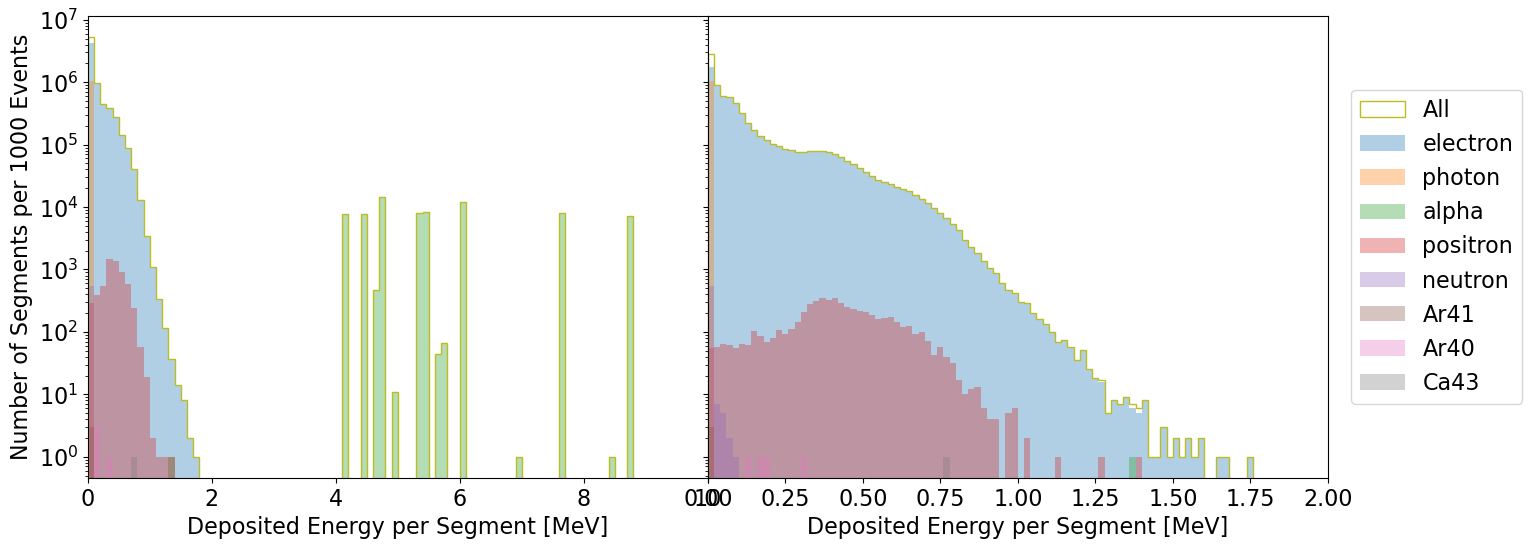

In [10]:
# Deposited energy per segment
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

dEBins = [ np.linspace(0., 10., 101), np.linspace(0., 2., 101) ]
fonts = 16

for i in range(2):
    ax[i].hist(dS.dE, bins = dEBins[i], histtype = 'step', label = 'All', color = colorAll)
    for ip in pdgDF.itertuples( index = False ):
        mask = dS["pdg_id"].eq(ip.pdgCode)
        dE = dS.loc[mask, 'dE']
        ax[i].hist(dE, bins = dEBins[i], histtype = 'stepfilled', alpha = 0.35,
                color = ip.color, label = ip.name)

        ax[i].set_xlabel('Deposited Energy per Segment [MeV]', fontsize = fonts)
        ax[i].tick_params(axis = "both", labelsize = fonts)
        ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Segments per 1000 Events', fontsize = fonts)
ax[0].set_xlim([0, 10])
ax[1].set_xlim([0, 2])
ax[1].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

Why do neutrons deposit so much energy?  It doesn't match the track-based plots.

Also, there are a lot of photons depositing energy.

In [11]:
dS.x_start.min(), dS.x_start.max(), dS.y_start.min(), dS.y_start.max(), dS.z_start.min(), dS.z_start.max()

(-1407.1539306640625,
 556.0715942382812,
 -668.2391357421875,
 320.73028564453125,
 448.62078857421875,
 1365.7437744140625)

In [12]:
dS.dEdx.min(), dS.dEdx.max()

(0.0, 348355.5)

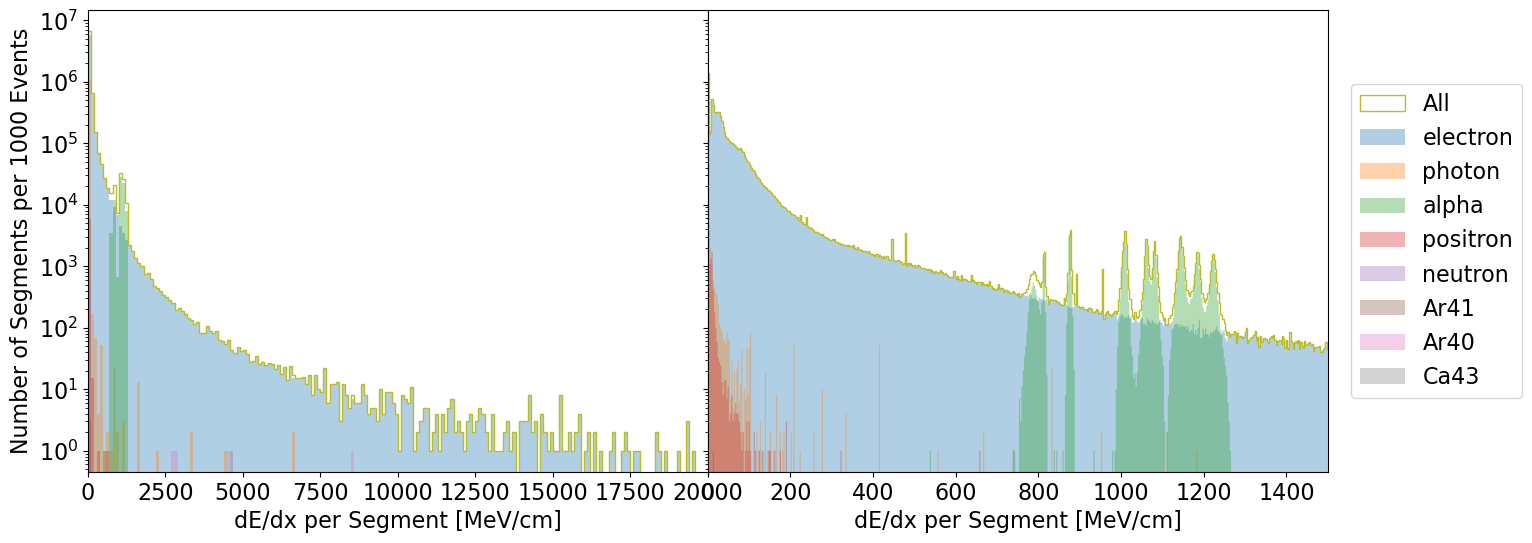

In [13]:
# dE/dx per segment
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

dEdxBins = [ np.linspace(0., 20000., 201), np.linspace(0., 1500., 501) ]
fonts = 16

for i in range(2):
    ax[i].hist(dS.dEdx, bins = dEdxBins[i], histtype = 'step', label = 'All', color = colorAll)
    for ip in pdgDF.itertuples( index = False ):
        mask = dS["pdg_id"].eq(ip.pdgCode)
        dEdx = dS.loc[mask, 'dEdx']
        ax[i].hist(dEdx, bins = dEdxBins[i], histtype = 'stepfilled', alpha = 0.35,
                color = ip.color, label = ip.name)

        ax[i].set_xlabel('dE/dx per Segment [MeV/cm]', fontsize = fonts)
        ax[i].tick_params(axis = "both", labelsize = fonts)
        ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Segments per 1000 Events', fontsize = fonts)
ax[0].set_xlim([0, 20000])
ax[1].set_xlim([0, 1500])
ax[1].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

### Segment Length

In [33]:
dS['dx'] = np.sqrt( (dS['x_end'] - dS['x_start'])**2 + (dS['y_end'] - dS['y_start'])**2 + (dS['z_end'] - dS['z_start'])**2 )

In [34]:
dS['dx'].min(), dS['dx'].max()

(0.0, 0.38459959626197815)

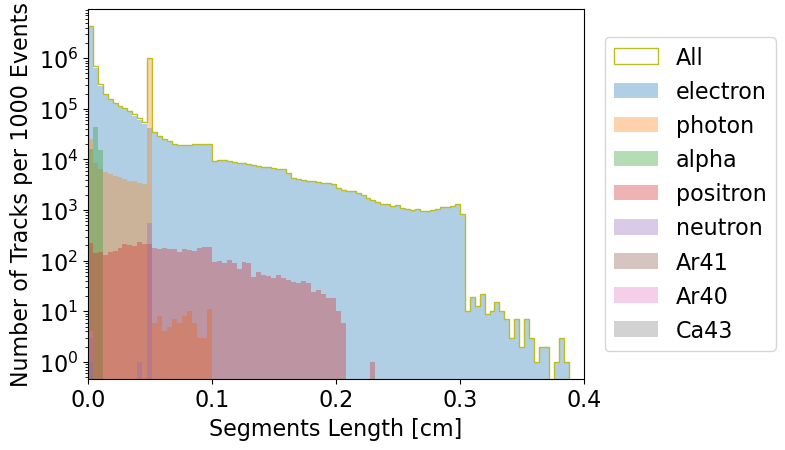

In [35]:
# Length of each segment
fig, ax = plt.subplots()

dxBins = np.linspace(0., 0.4, 101)
fonts = 16

ax.hist(dS.dx, bins = dxBins, histtype = 'step', label = 'All', color = colorAll)
for ip in pdgDF.itertuples( index = False ):
    mask = dS["pdg_id"].eq(ip.pdgCode)
    ax.hist(dS.loc[mask, 'dx'], bins = dxBins, histtype = 'stepfilled', alpha = 0.35,
            color = ip.color, label = ip.name)

ax.set_xlabel('Segments Length [cm]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')

ax.set_ylabel('Number of Tracks per 1000 Events', fontsize = fonts)
ax.set_xlim([0, 0.4])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

### Position and Time

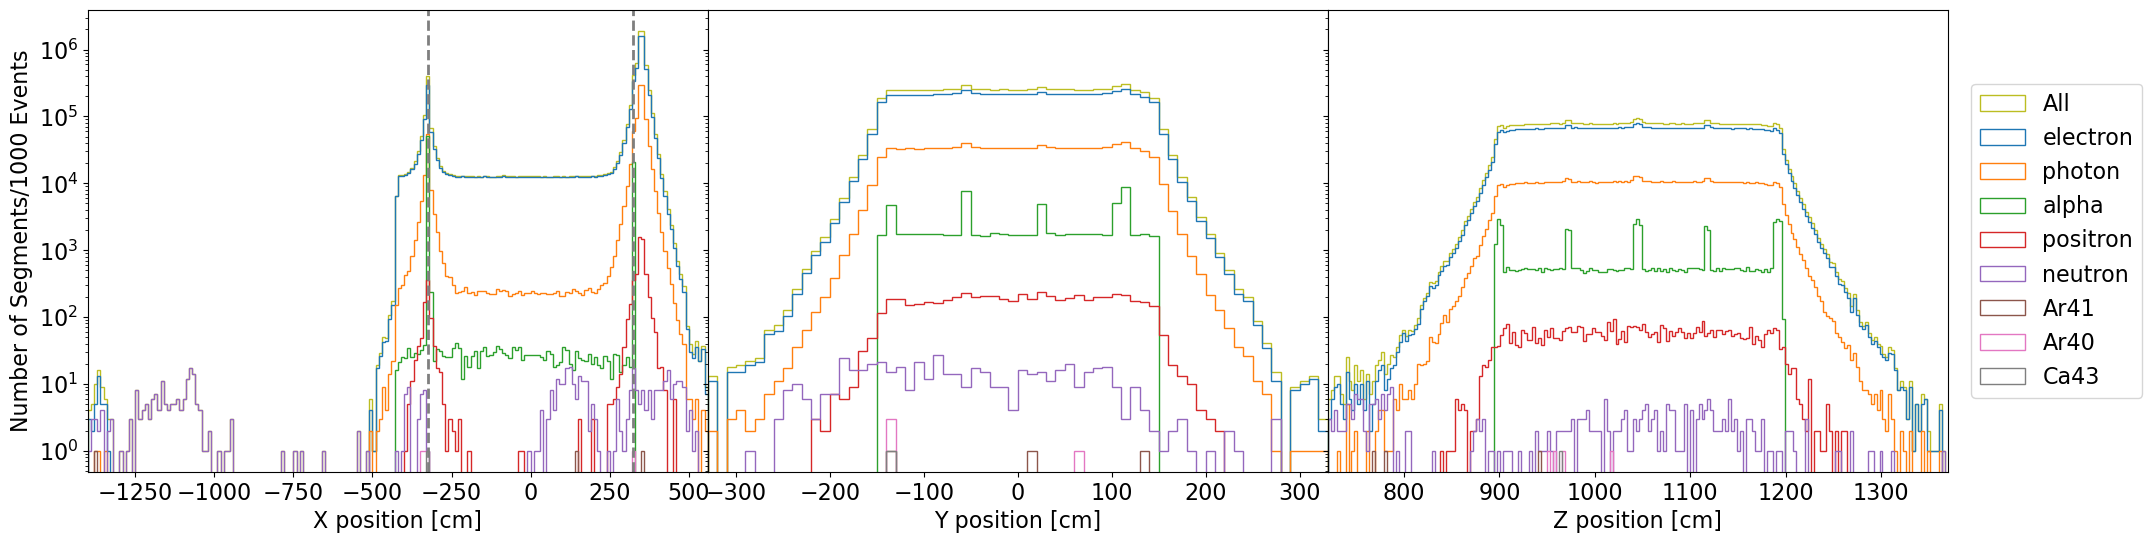

In [14]:
# X, Y, Z of the segment starting points, 10cm/bin
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-1400, 560, 197)
ybins = np.linspace(-330, 330, 67)
zbins = np.linspace(720, 1370, 210)

fonts = 16

## X
ax[0].hist(dS.x_start, bins = xbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[0].hist(dS.loc[dS['pdg_id'].eq(radMap.pdgCode), 'x_start'], bins = xbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fonts)
ax[0].set_ylabel('Number of Segments/1000 Events', fontsize = fonts)
ax[0].set_xlim([-1400, 560])

## Y
ax[1].hist(dS['y_start'], bins = ybins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[1].hist(dS.loc[dS['pdg_id'].eq(radMap.pdgCode), 'y_start'], bins = ybins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[1].set_xlabel('Y position [cm]', fontsize = fonts)
ax[1].set_xlim([-330, 330])

## Z
ax[2].hist(dS['z_start'], bins = zbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[2].hist(dS.loc[dS['pdg_id'].eq(radMap.pdgCode), 'z_start'], bins = zbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[2].set_xlabel('Z position [cm]', fontsize = fonts)
ax[2].set_xlim([720, 1370])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

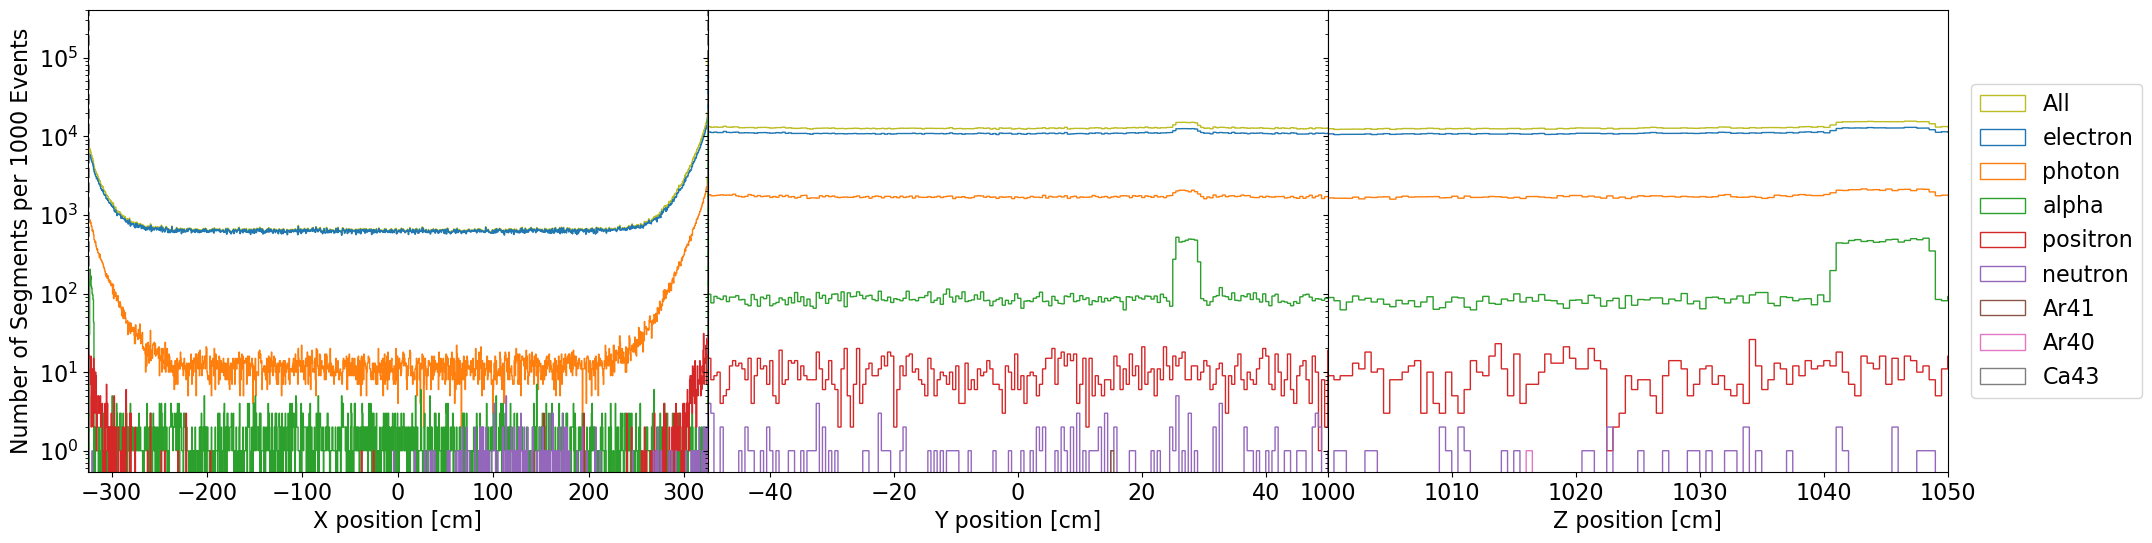

In [15]:
# X, Y, Z of the track starting points - further zoom in, 5mm/bin
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-1400, 560, 3921)
ybins = np.linspace(-330, 330, 1321)
zbins = np.linspace(720, 1370, 1301)

fonts = 16

## X
ax[0].hist(dS.x_start, bins = xbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[0].hist(dS.loc[dS['pdg_id'].eq(radMap.pdgCode), 'x_start'], bins = xbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fonts)
ax[0].set_ylabel('Number of Segments per 1000 Events', fontsize = fonts)
ax[0].set_xlim([-325, 325])

## Y
ax[1].hist(dS['y_start'], bins = ybins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[1].hist(dS.loc[dS['pdg_id'].eq(radMap.pdgCode), 'y_start'], bins = ybins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[1].set_xlabel('Y position [cm]', fontsize = fonts)
ax[1].set_xlim([-50, 50])

## Z
ax[2].hist(dS['z_start'], bins = zbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[2].hist(dS.loc[dS['pdg_id'].eq(radMap.pdgCode), 'z_start'], bins = zbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[2].set_xlabel('Z position [cm]', fontsize = fonts)
ax[2].set_xlim([1000, 1050])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

In [16]:
dS.t_start.min(), dS.t_start.max(), dS.t0.min(), dS.t0.max(), dS.t.min(), dS.t.max()

(0.0, 0.0, -4284.997836998894, 5452.94554020901, 0.0, 0.0)

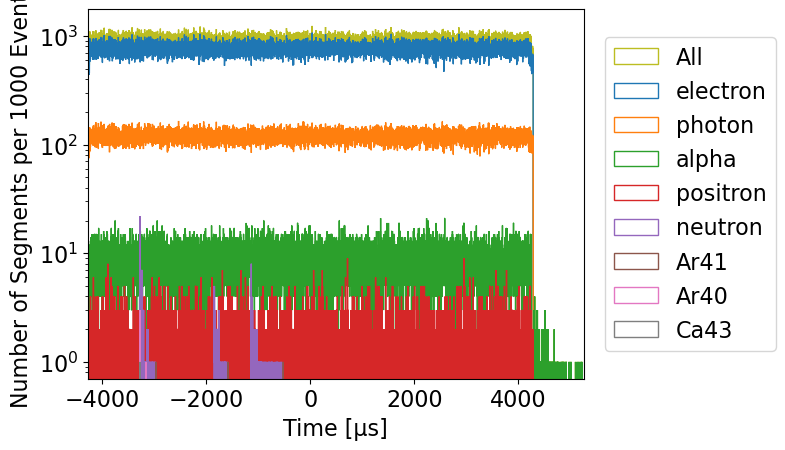

In [17]:
fig, ax = plt.subplots()

tBins = np.linspace(-4285, 5255, 9741)
fonts = 16

ax.hist(dS.t0, bins = tBins, histtype = 'step', label = 'All', color = colorAll)
for ip in pdgDF.itertuples( index = False ):
    mask = dS["pdg_id"].eq(ip.pdgCode)
    ax.hist(dS[mask].t0, bins = tBins, histtype = 'step', # alpha = 0.35,
            color = ip.color, label = ip.name)

ax.set_xlabel('Time [µs]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')

ax.set_ylabel('Number of Segments per 1000 Events', fontsize = fonts)
ax.set_xlim([-4285, 5255])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

The x, y, z, t distributions of segments look similar to those of tracks.

The only significant difference I can tell so far is the neutron contributions - neutrinos have a visible contribution in segments, but not in tracks.

## Segments to Tracks

In [18]:
dS.file_traj_id.max()

np.uint32(7544618)

In [19]:
len(dT)

7544619

In [20]:
# Group segments from the same track ID

dSperTrack = (
            dS.groupby("file_traj_id", as_index = False)
            .agg(
            pdg_id = ("pdg_id", "first"),
            nSegments = ("file_traj_id", "size"), # count rows per file_traj_id
            dE = ("dE", "sum"),
                )
            )
dSperTrack

,file_traj_id,pdg_id,nSegments,dE
0,0,11,1,0.102955
1,1,11,1,0.272483
2,2,11,1,0.091932
3,3,11,1,0.010307
4,4,11,1,0.354154
...,...,...,...,...
7540648,7544614,11,1,0.010890
7540649,7544615,11,1,0.014933
7540650,7544616,11,1,0.024414
7540651,7544617,11,1,0.013557


In [21]:
dSperTrack.nSegments.min(), dSperTrack.nSegments.max()

(1, 218)

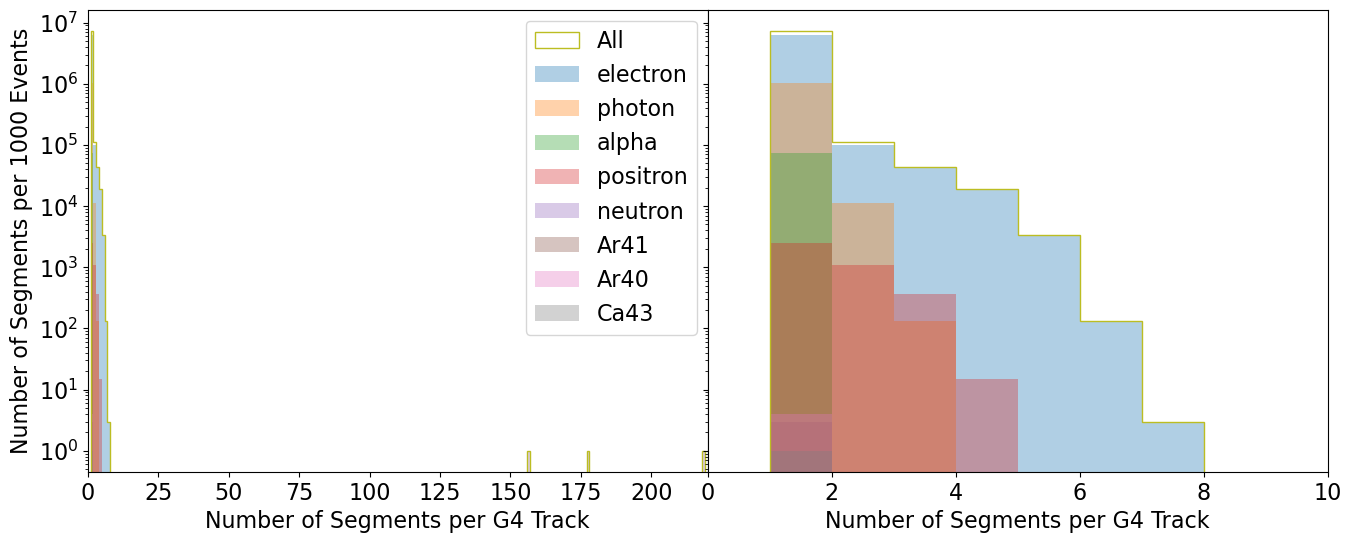

In [22]:
# Number of segments per G4 track
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

nSegBins = np.linspace(0, 220, 221)
fonts = 16

for i in range(2):
    ax[i].hist(dSperTrack.nSegments, bins = nSegBins, histtype = 'step', label = 'All', color = colorAll)
    for ip in pdgDF.itertuples( index = False ):
        mask = dSperTrack['pdg_id'].eq(ip.pdgCode)
        ax[i].hist(dSperTrack.loc[mask, 'nSegments'], bins = nSegBins, histtype = 'stepfilled', alpha = 0.35,
                        color = ip.color, label = ip.name)

        ax[i].set_xlabel('Number of Segments per G4 Track', fontsize = fonts)
        ax[i].tick_params(axis = "both", labelsize = fonts)
        ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Segments per 1000 Events', fontsize = fonts)
ax[0].set_xlim([0, 220])
ax[1].set_xlim([0, 10])
ax[0].legend(fontsize = fonts)

In [23]:
dSperTrack[dSperTrack.nSegments>10]

,file_traj_id,pdg_id,nSegments,dE
812169,812585,2112,156,0.010697
4101267,4103411,2112,177,0.004330
6042222,6045400,2112,218,0.919167


All the particles (G4 tracks) create < 10 segments, except a few neutrons

In [24]:
dSperTrack.dE.min(), dSperTrack.dE.max()

(1.4430000192078296e-05, 8.785100936889648)

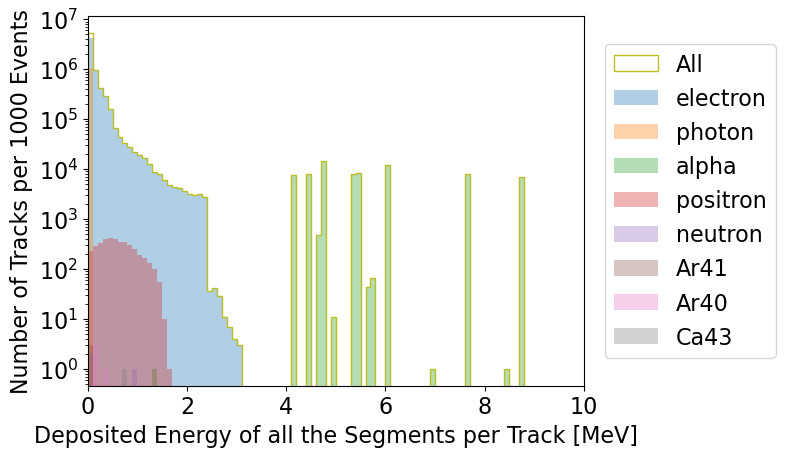

In [25]:
# Deposited energy of all the segments from the same G4 track
fig, ax = plt.subplots()

dEBins = np.linspace(0., 10., 101)
fonts = 16

ax.hist(dSperTrack.dE, bins = dEBins, histtype = 'step', label = 'All', color = colorAll)
for ip in pdgDF.itertuples( index = False ):
    mask = dSperTrack["pdg_id"].eq(ip.pdgCode)
    ax.hist(dSperTrack.loc[mask, 'dE'], bins = dEBins, histtype = 'stepfilled', alpha = 0.35,
            color = ip.color, label = ip.name)

ax.set_xlabel('Deposited Energy of all the Segments per Track [MeV]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')

ax.set_ylabel('Number of Tracks per 1000 Events', fontsize = fonts)
ax.set_xlim([0, 10])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

Quite similar to the deposited energy per G4 track, except photons.

In [26]:
dSperTrack[dSperTrack.pdg_id == 22].dE.max()

0.0033668691758066416

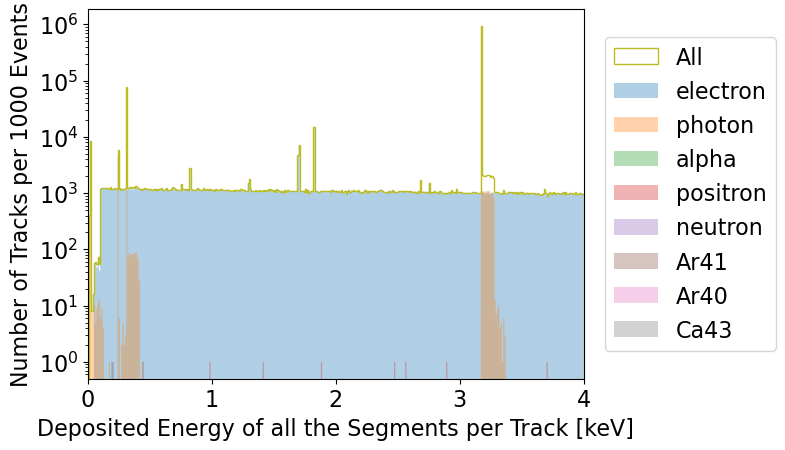

In [27]:
# How much energy the photons deposit?
fig, ax = plt.subplots()

dEBins = np.linspace(0., 4., 401)
fonts = 16

ax.hist(dSperTrack.dE*1000, bins = dEBins, histtype = 'step', label = 'All', color = colorAll)
for ip in pdgDF.itertuples( index = False ):
    mask = dSperTrack["pdg_id"].eq(ip.pdgCode)
    ax.hist(dSperTrack.loc[mask, 'dE']*1000, bins = dEBins, histtype = 'stepfilled', alpha = 0.35,
            color = ip.color, label = ip.name)

ax.set_xlabel('Deposited Energy of all the Segments per Track [keV]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')

ax.set_ylabel('Number of Tracks per 1000 Events', fontsize = fonts)
ax.set_xlim([0, 4])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

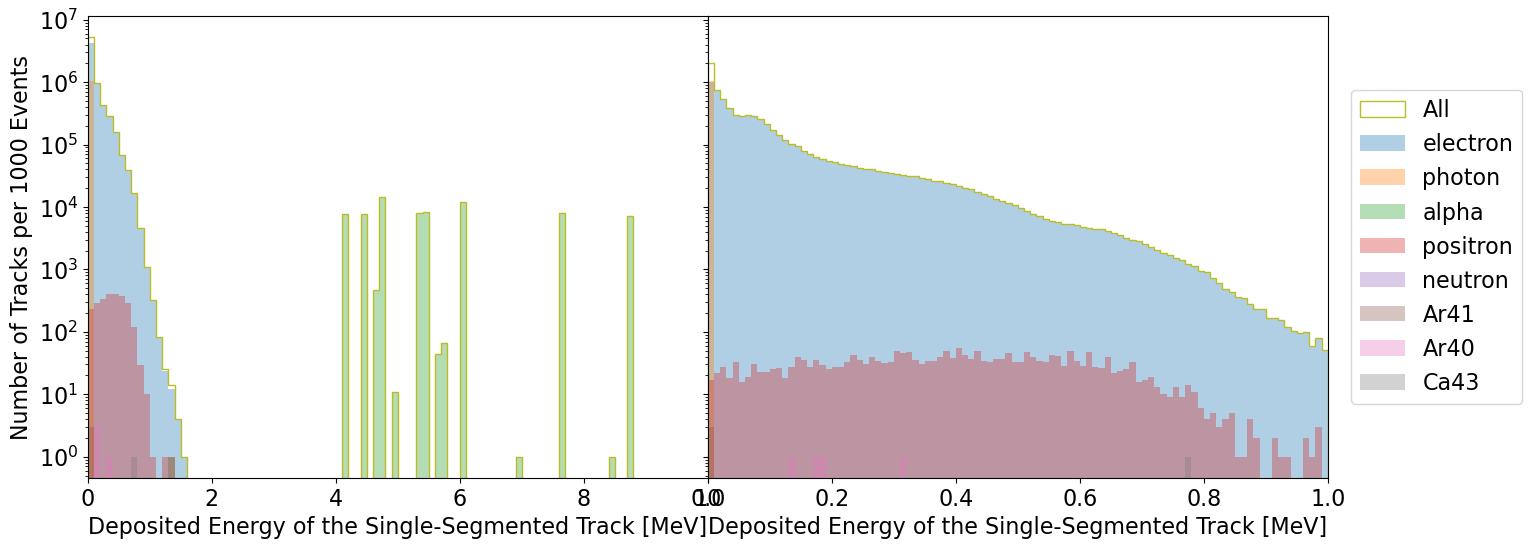

In [32]:
# Deposited energy of the tracks with only one segment
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

dEBins = [ np.linspace(0., 10., 101), np.linspace(0., 1., 101) ]
fonts = 16

for i in range(2):
    mask = dSperTrack['nSegments'].eq(1)

    ax[i].hist(dSperTrack.loc[mask, 'dE'], bins = dEBins[i], histtype = 'step', label = 'All', color = colorAll)
    for ip in pdgDF.itertuples( index = False ):
        mask = dSperTrack['nSegments'].eq(1) & dSperTrack["pdg_id"].eq(ip.pdgCode)
        ax[i].hist(dSperTrack.loc[mask, 'dE'], bins = dEBins[i], histtype = 'stepfilled', alpha = 0.35,
                color = ip.color, label = ip.name)

    ax[i].set_xlabel('Deposited Energy of the Single-Segmented Track [MeV]', fontsize = fonts)
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Tracks per 1000 Events', fontsize = fonts)
ax[0].set_xlim([0, 10])
ax[1].set_xlim([0, 1])
ax[1].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)
